### US Obesity Map (Q1 & Q2)

Plot a proper map showing the obesity spread over different states of US, highlighting the states with maximum and minimum obesity.

**Visualization Technique:** Choropleth Map with Data Smoothing
- Successfully visualizes obesity rates across US states using shapefile data
- Color gradient (yellow to red) effectively shows obesity distribution across geographic areas
- Data smoothing technique: spreading point-based obesity values across state polygon areas
- **Key Finding:** Louisiana has the highest obesity rate (36.2%), while Colorado has the lowest (20.2%)
- Clear geographic pattern: Southern states show higher obesity rates compared to western and northeastern states

The choropleth map demonstrates data smoothing by taking discrete data points (state obesity rates) and spreading them across continuous geographic areas (state boundaries).

In [ ]:
# Install Required Libraries
%pip install pandas numpy matplotlib geopandas shapely pyproj fiona scipy geoplot us geopandas geoplot pandas shapely scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 24.5 MB/s eta 0:00:00


In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs
from scipy.spatial import Voronoi
from scipy.interpolate import griddata
from shapely.geometry import Point
import us as us
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load obesity data
obesity_df = pd.read_csv('National_Obesity_By_State.csv')

# Load shapefile for US states
us_states = gpd.read_file('US_State.shp')

# Display first few rows
print("Obesity Data:")
print(obesity_df.head())
print("\nShapefile Data:")
print(us_states.head())

Obesity Data:
   FID        NAME  Obesity  SHAPE_Length    SHAPE_Area
0    1       Texas     32.4  1.540832e+07  7.672329e+12
1    2  California     24.2  1.451870e+07  5.327809e+12
2    3    Kentucky     34.6  6.346699e+06  1.128830e+12
3    4     Georgia     30.7  5.795596e+06  1.652980e+12
4    5   Wisconsin     30.7  6.806782e+06  1.567816e+12

Shapefile Data:
   OBJECTID   FIPS  FIPSNum StateFIPS  StateFIPSN   StateName  CensusReg  \
0         1  02000     2000        02           2      Alaska       West   
1         9  53000    53000        53          53  Washington       West   
2        10  23000    23000        23          23       Maine  Northeast   
3        11  27000    27000        27          27   Minnesota    Midwest   
4        18  26000    26000        26          26    Michigan    Midwest   

            CensusDiv     XCentroid     YCentroid Notes  \
0             Pacific -1.882092e+06  2.310348e+06  None   
1             Pacific -1.837353e+06  1.340481e+06  None   

In [ ]:
# Merge the shapefile with obesity data
us_states_obesity = us_states.merge(obesity_df, left_on='StateName', right_on='NAME', how='left')

# Find states with max and min obesity
max_obesity_state = us_states_obesity.loc[us_states_obesity['Obesity'].idxmax()]
min_obesity_state = us_states_obesity.loc[us_states_obesity['Obesity'].idxmin()]

print(f"State with Maximum Obesity: {max_obesity_state['StateName']} ({max_obesity_state['Obesity']}%)")
print(f"State with Minimum Obesity: {min_obesity_state['StateName']} ({min_obesity_state['Obesity']}%)")

State with Maximum Obesity: Louisiana (36.2%)
State with Minimum Obesity: Colorado (20.2%)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Map saved to viz/eps/q1_q2_us_obesity_map.eps


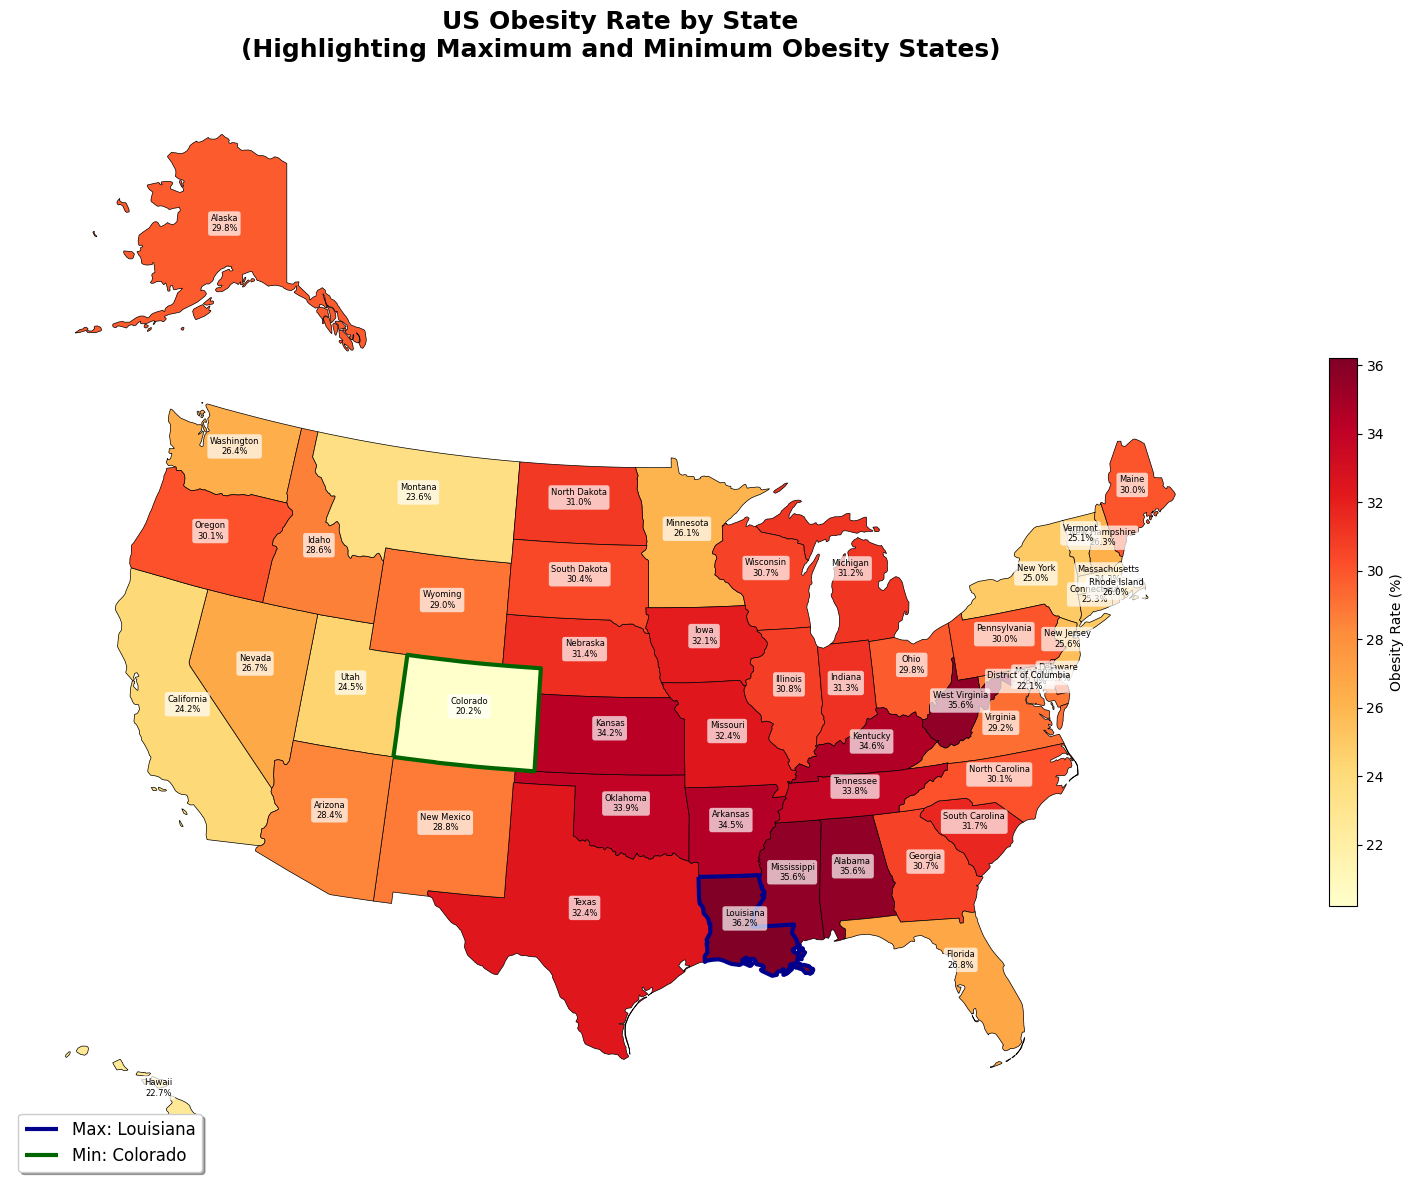


📊 Context:
• The map visualizes obesity rates across US states using a yellow-orange-red color scale.
• Darker red indicates higher obesity rates, while lighter yellow indicates lower rates.
• Louisiana has the MAXIMUM obesity rate at 36.2% (highlighted with dark blue border).
• Colorado has the MINIMUM obesity rate at 20.2% (highlighted with dark green border).
• Southern states tend to have higher obesity rates compared to western and northeastern states.


In [ ]:
# Create the obesity map
fig, ax = plt.subplots(1, 1, figsize=(20, 12))

# Plot all states with obesity data
us_states_obesity.plot(column='Obesity',
                        ax=ax,
                        legend=True,
                        cmap='YlOrRd',
                        edgecolor='black',
                        linewidth=0.5,
                        legend_kwds={'label': "Obesity Rate (%)", 'orientation': "vertical", 'shrink': 0.5})

# Highlight state with maximum obesity (red border)
max_state_geom = us_states_obesity[us_states_obesity['StateName'] == max_obesity_state['StateName']]
max_state_geom.boundary.plot(ax=ax, color='darkblue', linewidth=3, label=f'Max: {max_obesity_state["StateName"]}')

# Highlight state with minimum obesity (green border)
min_state_geom = us_states_obesity[us_states_obesity['StateName'] == min_obesity_state['StateName']]
min_state_geom.boundary.plot(ax=ax, color='darkgreen', linewidth=3, label=f'Min: {min_obesity_state["StateName"]}')

# Add state labels
for idx, row in us_states_obesity.iterrows():
    if pd.notna(row['Obesity']):
        centroid = row['geometry'].centroid
        ax.annotate(text=f"{row['StateName']}\n{row['Obesity']}%",
                   xy=(centroid.x, centroid.y),
                   ha='center',
                   fontsize=6,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_title('US Obesity Rate by State\n(Highlighting Maximum and Minimum Obesity States)',
             fontsize=18, fontweight='bold', pad=20)
ax.axis('off')
ax.legend(loc='lower left', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()

# Save the map as EPS to viz/eps directory
import os
os.makedirs('viz/eps', exist_ok=True)
plt.savefig('viz/eps/q1_q2_us_obesity_map.eps', format='eps', dpi=300, bbox_inches='tight')
print("Map saved to viz/eps/q1_q2_us_obesity_map.eps")

plt.show()

print("\n📊 Context:")
print(f"• The map visualizes obesity rates across US states using a yellow-orange-red color scale.")
print(f"• Darker red indicates higher obesity rates, while lighter yellow indicates lower rates.")
print(f"• {max_obesity_state['StateName']} has the MAXIMUM obesity rate at {max_obesity_state['Obesity']}% (highlighted with dark blue border).")
print(f"• {min_obesity_state['StateName']} has the MINIMUM obesity rate at {min_obesity_state['Obesity']}% (highlighted with dark green border).")
print(f"• Southern states tend to have higher obesity rates compared to western and northeastern states.")

# Question 2:

Map saved to viz/eps/q1_q2_us_obesity_voronoi_elevation_map_smoothed.eps


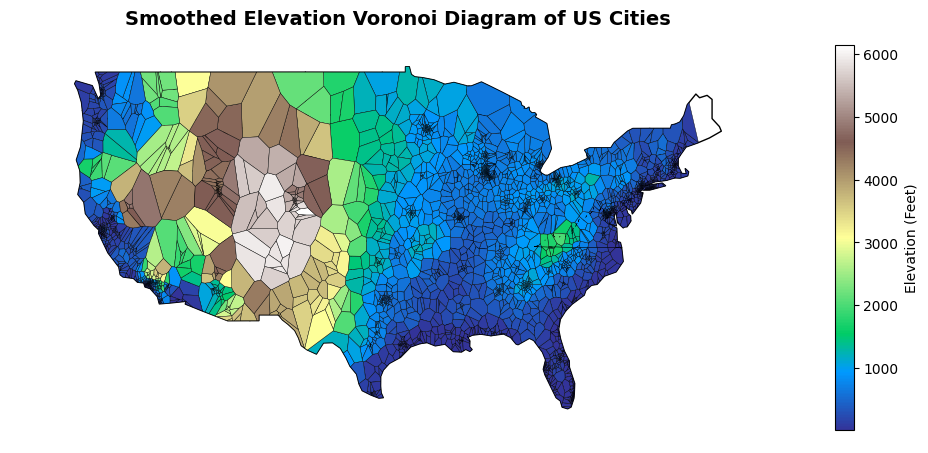

In [ ]:
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
import numpy as np
from scipy.spatial import Voronoi, KDTree
from scipy.ndimage import gaussian_filter1d

# -------------------------------------------------------
# Load base data
# -------------------------------------------------------
path_us = gplt.datasets.get_path("contiguous_usa")
us_map = gpd.read_file(path_us)

path_cities = gplt.datasets.get_path("usa_cities")
cities_gdf = gpd.read_file(path_cities)

# Extract coordinates and elevations
points = np.array(list(zip(cities_gdf.geometry.x, cities_gdf.geometry.y)))
elevations = cities_gdf["ELEV_IN_FT"].astype(float).values

# -------------------------------------------------------
# Compute raw Voronoi
# -------------------------------------------------------
vor = Voronoi(points)

# Function to convert Voronoi regions to shapely polygons
def voronoi_polygons(vor, clip_shape):
    polygons = []
    for region_idx in vor.point_region:
        region = vor.regions[region_idx]
        if -1 in region or len(region) == 0:
            polygons.append(None)
            continue
        poly = Polygon(vor.vertices[region])
        poly = poly.intersection(clip_shape)  # clip to US
        polygons.append(poly)
    return polygons

us_union = unary_union(us_map.geometry)
polygons = voronoi_polygons(vor, us_union)

# Build GeoDataFrame with original index for mapping
temp_vor_gdf = gpd.GeoDataFrame({
    "geometry": polygons,
    "elevation_raw": elevations,
    "original_point_index": range(len(cities_gdf)) # Store the original index
})

# Drop rows with None geometries
vor_gdf = temp_vor_gdf.dropna(subset=['geometry']).copy() # Use .copy() to avoid SettingWithCopyWarning

# -------------------------------------------------------
# Apply smoothing
# -------------------------------------------------------
k = 8 # Number of neighbors for smoothing
# Create a KDTree for neighbor lookup using the full set of points
# to ensure neighbor search considers all possible nearby cities.
tree = KDTree(points)

# Get the indices of the original points that correspond to the valid geometries in vor_gdf
valid_original_indices = vor_gdf['original_point_index'].values

smoothed = []
# Iterate through the original points that correspond to the valid Voronoi cells
for original_idx in valid_original_indices:
    pt = points[original_idx] # Get the coordinates of the original point
    dists, idx = tree.query(pt, k=k) # Query for neighbors in the full point set
    neighbor_elevs = elevations[idx] # Get elevations of these neighbors from the full elevations array

    # Gaussian smoothing of neighboring values (Increased sigma for more pronounced smoothing)
    weights = np.exp(-(dists**2) / (2 * 2.0**2)) # Changed 0.5 to 2.0 here
    weights /= weights.sum()

    smoothed_value = np.sum(neighbor_elevs * weights)
    smoothed.append(smoothed_value)

# Assign the smoothed values to the vor_gdf. The order matches due to iteration over valid_original_indices.
vor_gdf["elevation_smoothed"] = smoothed

# Drop the temporary 'original_point_index' column
vor_gdf = vor_gdf.drop(columns=['original_point_index'])

# -------------------------------------------------------
# Plot the Voronoi Diagram
# -------------------------------------------------------
# Change projection to PlateCarree for a more standard North-up view
fig, ax = plt.subplots(1, 1, figsize=(10, 8),
                       subplot_kw={'projection': gcrs.PlateCarree()})

# Plot colored Voronoi cells
vor_gdf = vor_gdf.set_crs(us_map.crs)
vor_gdf.to_crs(us_map.crs).plot(
    ax=ax,
    column="elevation_smoothed",
    cmap="terrain",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    legend_kwds={'label': "Elevation (Feet)", 'orientation': "vertical", 'shrink': 0.5}
)

# Add US boundaries
gplt.polyplot(
    us_map,
    ax=ax,
    edgecolor='black',
    facecolor='none',
)

ax.set_title(
    'Smoothed Elevation Voronoi Diagram of US Cities',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
# Save the map as EPS to viz/eps directory
import os
os.makedirs('viz/eps', exist_ok=True)
plt.savefig('viz/eps/q1_q2_us_obesity_voronoi_elevation_map_smoothed.eps', format='eps', dpi=300, bbox_inches='tight')
print("Map saved to viz/eps/q1_q2_us_obesity_voronoi_elevation_map_smoothed.eps")
plt.show()

In [ ]:
cities_gdf['longitude'] = cities_gdf.geometry.x
cities_gdf['latitude'] = cities_gdf.geometry.y

# Group by 'STATE' and calculate the mean for elevation, longitude, and latitude
grouped_by_state = cities_gdf.groupby('STATE').agg(
    mean_elevation=('ELEV_IN_FT', 'mean'),
    mean_longitude=('longitude', 'mean'),
    mean_latitude=('latitude', 'mean')
).reset_index()

# Create Point geometries from the mean longitude and latitude
grouped_by_state['geometry'] = grouped_by_state.apply(
    lambda row: Point(row['mean_longitude'], row['mean_latitude']), axis=1
)

# Convert to GeoDataFrame and set the CRS to match cities_gdf
state_avg_gdf = gpd.GeoDataFrame(
    grouped_by_state,
    geometry='geometry',
    crs=cities_gdf.crs
)

print("Aggregated State-level GeoDataFrame (first 5 rows):")
print(state_avg_gdf.head())
print(f"\nShape of the new GeoDataFrame: {state_avg_gdf.shape}")

Aggregated State-level GeoDataFrame (first 5 rows):
  STATE  mean_elevation  mean_longitude  mean_latitude  \
0    AK      259.500000     -144.959792      62.303681   
1    AL      513.593750      -86.662643      33.058717   
2    AR      508.743590      -92.618167      35.066101   
3    AZ     2257.566667     -111.944084      33.316710   
4    CA      530.708609     -119.497906      35.656266   

                      geometry  
0  POINT (-144.95979 62.30368)  
1   POINT (-86.66264 33.05872)  
2    POINT (-92.61817 35.0661)  
3  POINT (-111.94408 33.31671)  
4  POINT (-119.49791 35.65627)  

Shape of the new GeoDataFrame: (52, 5)


In [ ]:
# Update 'points' with state-averaged longitudes and latitudes
points = np.array(list(zip(state_avg_gdf.geometry.x, state_avg_gdf.geometry.y)))

# Update 'elevations' with state-averaged mean_elevation
elevations = state_avg_gdf['mean_elevation'].values

print(f"Updated 'points' array shape: {points.shape}")
print(f"Updated 'elevations' array shape: {elevations.shape}")
print("First 5 state-averaged points:")
print(points[:5])
print("First 5 state-averaged elevations:")
print(elevations[:5])

Updated 'points' array shape: (52, 2)
Updated 'elevations' array shape: (52,)
First 5 state-averaged points:
[[-144.95979167   62.30368055]
 [ -86.66264322   33.05871685]
 [ -92.6181668    35.06610118]
 [-111.94408413   33.31671001]
 [-119.49790605   35.65626649]]
First 5 state-averaged elevations:
[ 259.5         513.59375     508.74358974 2257.56666667  530.70860927]


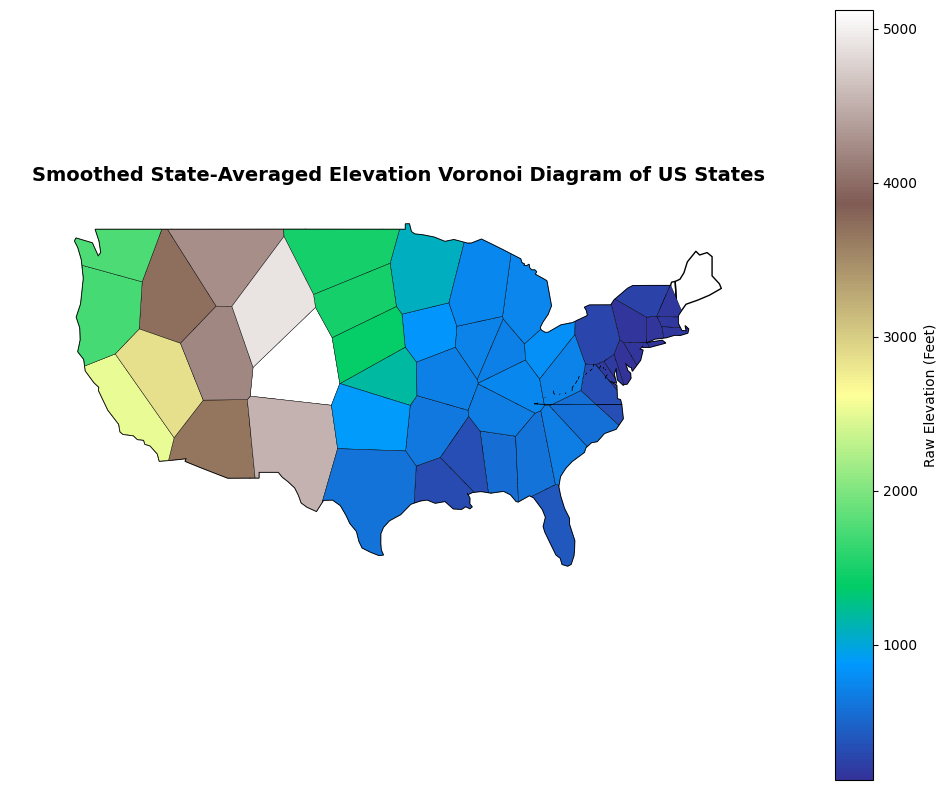

In [ ]:
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
import numpy as np
from scipy.spatial import Voronoi, KDTree
from scipy.ndimage import gaussian_filter1d

# -------------------------------------------------------
# Load base data
# -------------------------------------------------------
path_us = gplt.datasets.get_path("contiguous_usa")
us_map = gpd.read_file(path_us)

path_cities = gplt.datasets.get_path("usa_cities")
cities_gdf = gpd.read_file(path_cities)

# Extract coordinates and elevations
# UPDATED: Use state_avg_gdf for points and elevations
points = np.array(list(zip(state_avg_gdf.geometry.x, state_avg_gdf.geometry.y)))
elevations = state_avg_gdf["mean_elevation"].values

# -------------------------------------------------------
# Compute raw Voronoi
# -------------------------------------------------------
vor = Voronoi(points)

# Function to convert Voronoi regions to shapely polygons
def voronoi_polygons(vor, clip_shape):
    polygons = []
    for region_idx in vor.point_region:
        region = vor.regions[region_idx]
        if -1 in region or len(region) == 0:
            polygons.append(None)
            continue
        poly = Polygon(vor.vertices[region])
        poly = poly.intersection(clip_shape)  # clip to US
        polygons.append(poly)
    return polygons

us_union = unary_union(us_map.geometry)
polygons = voronoi_polygons(vor, us_union)

# Build GeoDataFrame with original index for mapping
temp_vor_gdf = gpd.GeoDataFrame({
    "geometry": polygons,
    "elevation_raw": elevations,
    "original_point_index": range(len(state_avg_gdf)) # Store the original index (for state-averaged data)
})

# Drop rows with None geometries
vor_gdf = temp_vor_gdf.dropna(subset=['geometry']).copy() # Use .copy() to avoid SettingWithCopyWarning

# -------------------------------------------------------
# Apply smoothing
# -------------------------------------------------------
k = 4 # Number of neighbors for smoothing
# Create a KDTree for neighbor lookup using the full set of points
# to ensure neighbor search considers all possible nearby cities.
tree = KDTree(points)

# Get the indices of the original points that correspond to the valid geometries in vor_gdf
valid_original_indices = vor_gdf['original_point_index'].values

smoothed = []
# Iterate through the original points that correspond to the valid Voronoi cells
for original_idx in valid_original_indices:
    pt = points[original_idx] # Get the coordinates of the original point
    dists, idx = tree.query(pt, k=k) # Query for neighbors in the full point set
    neighbor_elevs = elevations[idx] # Get elevations of these neighbors from the full elevations array

    # Gaussian smoothing of neighboring values (Increased sigma for more pronounced smoothing)
    weights = np.exp(-(dists**2) / (2 * 10.0**2)) # Changed 0.5 to 2.0 here
    weights /= weights.sum()

    smoothed_value = np.sum(neighbor_elevs * weights)
    smoothed.append(smoothed_value)

# Assign the smoothed values to the vor_gdf. The order matches due to iteration over valid_original_indices.
vor_gdf["elevation_smoothed"] = smoothed

# Drop the temporary 'original_point_index' column
vor_gdf = vor_gdf.drop(columns=['original_point_index'])

# -------------------------------------------------------
# Plot the Voronoi Diagram
# -------------------------------------------------------
# Change projection to PlateCarree for a more standard North-up view
fig, ax = plt.subplots(1, 1, figsize=(10, 8),
                       subplot_kw={'projection': gcrs.PlateCarree()})

# Plot colored Voronoi cells
vor_gdf = vor_gdf.set_crs(us_map.crs)
vor_gdf.to_crs(us_map.crs).plot(
    ax=ax,
    column="elevation_smoothed",
    cmap="terrain",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    legend_kwds={'label': "Raw Elevation (Feet)", 'orientation': "vertical"}

)

# Add US boundaries
gplt.polyplot(
    us_map,
    ax=ax,
    edgecolor='black',
    facecolor='none',
)

# Plot city points
# gplt.pointplot(
#     cities_gdf,
#     ax=ax,
#     s=5, # Changed markersize to s
#     color='red',
#     edgecolor='black',
#     linewidth=0.5,
#     alpha=0.7,
#     zorder=5,
# )

ax.set_title(
    'Smoothed State-Averaged Elevation Voronoi Diagram of US States',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('voronoi_elevation_map_smoothed.png', dpi=300, bbox_inches='tight')
plt.show()

### Question 3: Distribution of School Levels Over States
Plot the distribution of School levels over states and indicate which has the highest and lowest of High and Elementary schools.

In [ ]:
# Load Public Schools data
schools = gpd.read_file('Public_Schools/Public_Schools/PublicSchools.shp')

print("Public Schools Data:")
print(schools.head())
print(f"\nTotal schools: {len(schools)}")
print(f"\nColumns: {schools.columns.tolist()}")
print(f"\nSchool Levels: {schools['LEVEL_'].unique()}")

print(schools["STATE"])

Public Schools Data:
   OBJECTID        NCESID                                           NAME  \
0         1  170330000017                       ALDEN-HEBRON HIGH SCHOOL   
1         2  370297001287                         WESTERLY HILLS ACADEMY   
2         3  180369000584                    NORTHWOOD ELEMENTARY SCHOOL   
3         4  040187003479  DR. GARY AND ANNETTE AUXIER ELEMENTARY SCHOOL   
4         5  040187003483                DR. CAMILLE CASTEEL HIGH SCHOOL   

              ADDRESS         CITY STATE    ZIP  ZIP4       TELEPHONE TYPE  \
0    9604 ILLINOIS ST       HEBRON    IL  60034  9618  (815) 648-2442    1   
1     4420 DENVER AVE    CHARLOTTE    NC  28208  3699  (980) 343-6021    1   
2  965 GRIZZLY CUB DR     FRANKLIN    IN  46131  1364  (317) 346-8900    1   
3    22700 S POWER RD  QUEEN CREEK    AZ  85142  4507  (480) 424-8400    1   
4    24901 S POWER RD  QUEEN CREEK    AZ  85142  8428  (480) 424-8100    1   

   ...   VAL_DATE                                   W

In [ ]:
# Aggregate school counts by state and level (exclude VI territory)
school_counts = schools[schools['STATE'] != 'VI'].groupby(['STATE', 'LEVEL_']).size().reset_index(name='Count')

# Pivot to get High and Elementary schools by state
school_pivot = school_counts.pivot(index='STATE', columns='LEVEL_', values='Count').fillna(0)

# Get High and Elementary school counts (levels are uppercase in data)
high_schools = school_pivot.get('HIGH', pd.Series(dtype=float))
elem_schools = school_pivot.get('ELEMENTARY', pd.Series(dtype=float))

print("States with Highest/Lowest High Schools (VI excluded):")
print(f"Highest: {high_schools.idxmax()} ({int(high_schools.max())} schools)")
print(f"Lowest: {high_schools.idxmin()} ({int(high_schools.min())} schools)")

print("\nStates with Highest/Lowest Elementary Schools (VI excluded):")
print(f"Highest: {elem_schools.idxmax()} ({int(elem_schools.max())} schools)")
print(f"Lowest: {elem_schools.idxmin()} ({int(elem_schools.min())} schools)")

States with Highest/Lowest High Schools (VI excluded):
Highest: TX (2193 schools)
Lowest: AS (7 schools)

States with Highest/Lowest Elementary Schools (VI excluded):
Highest: CA (5124 schools)
Lowest: GU (12 schools)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


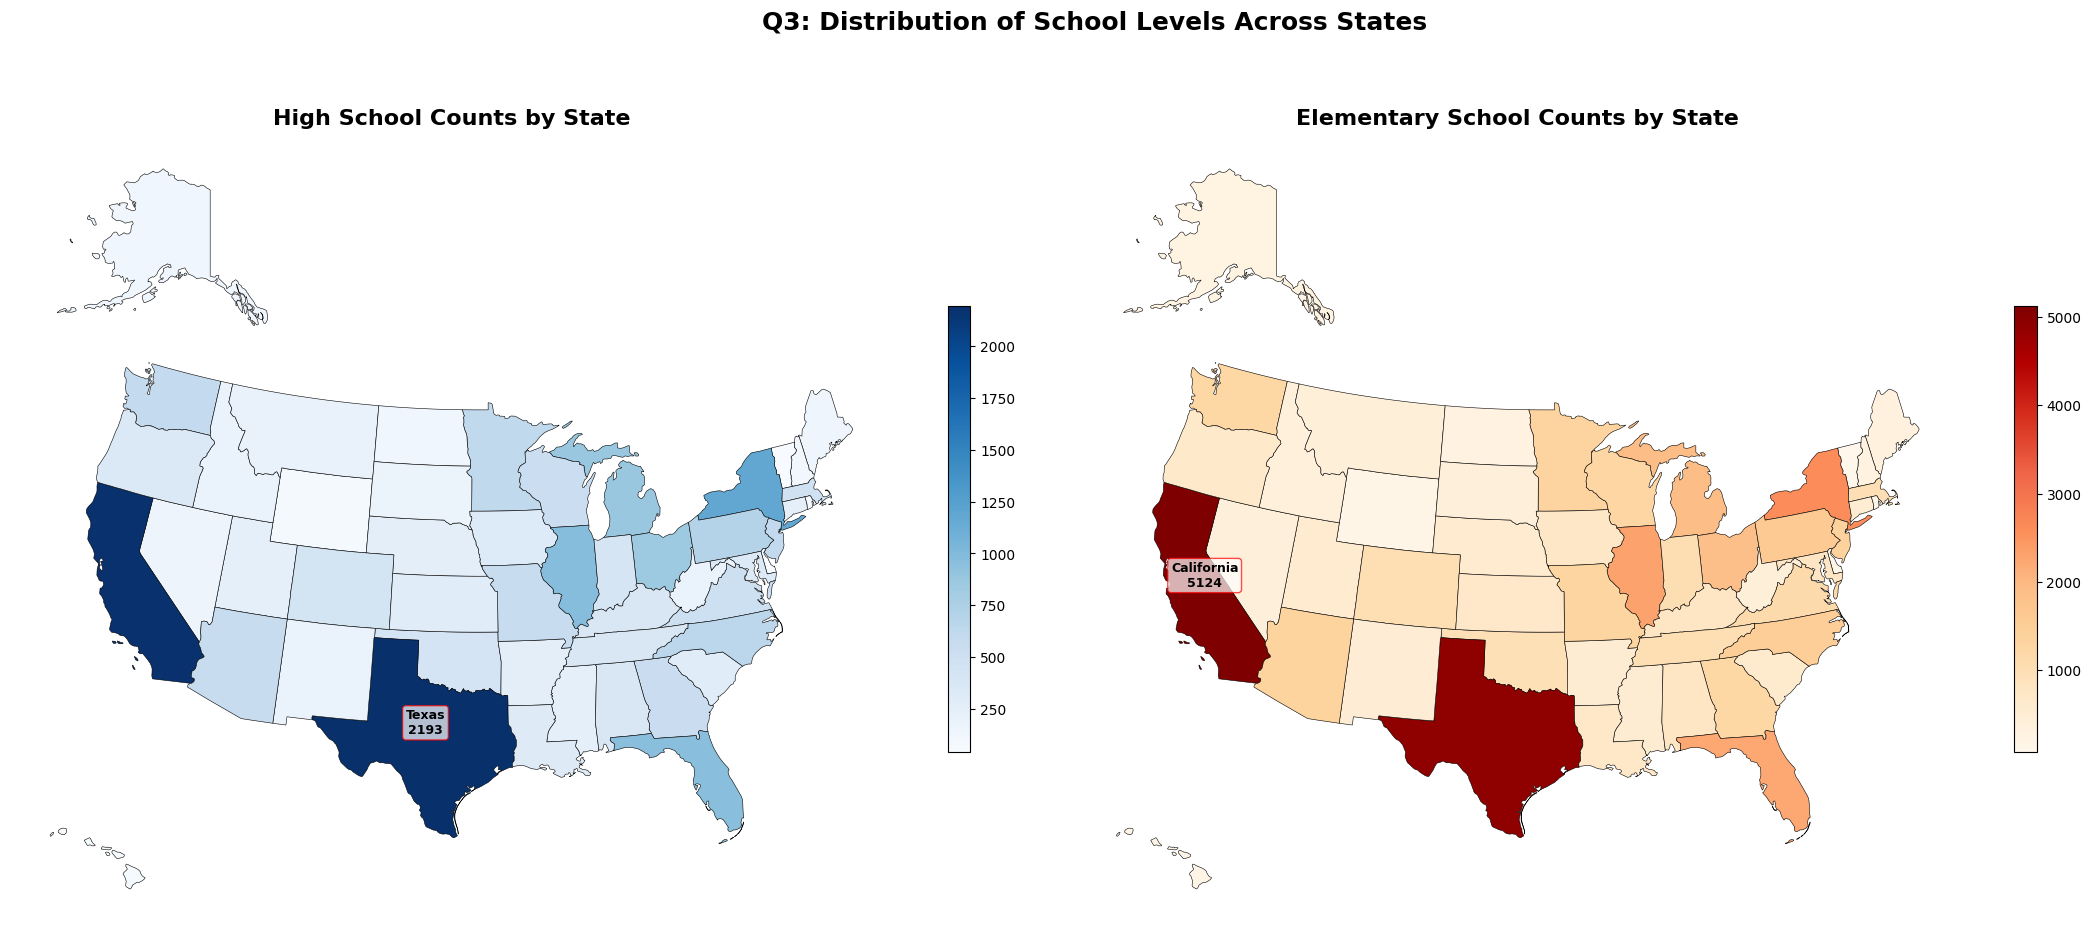


✅ Saved map figure to viz/eps/q3_school_levels_maps.eps

📊 Context (Q3 Maps):
• Highest High Schools: TX with 2193 schools (red border)
• Lowest High Schools: AS with 7 schools (green border)
• Highest Elementary Schools: CA with 5124 schools (red border)
• Lowest Elementary Schools: GU with 12 schools (green border)


In [ ]:
# Q3 Map Visualization: High vs Elementary School Counts by State
import os
import matplotlib.pyplot as plt
import geopandas as gpd

# State abbreviation mapping
state_abbrev_to_name = {state.abbr: state.name for state in us.states.STATES}

# Prepare data with state names
high_df = high_schools.reset_index()
high_df.columns = ['STATE','HighSchools']
high_df['StateName'] = high_df['STATE'].map(state_abbrev_to_name)


elem_df = elem_schools.reset_index()
elem_df.columns = ['STATE','ElementarySchools']
elem_df['StateName'] = elem_df['STATE'].map(state_abbrev_to_name)

# Load shapefile and merge
us_states = gpd.read_file('US_State.shp')
high_geo = us_states.merge(high_df, on='StateName', how='inner')
elem_geo = us_states.merge(elem_df, on='StateName', how='inner')

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# High Schools Map
high_geo.plot(column='HighSchools', ax=axes[0], cmap='Blues', edgecolor='black', linewidth=0.4,
              legend=True, missing_kwds={'color':'lightgrey'}, legend_kwds={'shrink':0.5})
axes[0].set_title('High School Counts by State', fontsize=16, fontweight='bold')
axes[0].axis('off')

# Annotate max and min for High Schools
max_high_state = high_schools.idxmax()
min_high_state = high_schools.idxmin()
for idx, row in high_geo.iterrows():
    if pd.notna(row.get('HighSchools')) and row.get('STATE') in [max_high_state, min_high_state]:
        centroid = row['geometry'].centroid
        axes[0].annotate(f"{row['StateName']}\n{int(row['HighSchools'])}",
                        xy=(centroid.x, centroid.y), ha='center', fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='red', alpha=0.7))

# Elementary Schools Map
elem_geo.plot(column='ElementarySchools', ax=axes[1], cmap='OrRd', edgecolor='black', linewidth=0.4,
              legend=True, missing_kwds={'color':'lightgrey'}, legend_kwds={'shrink':0.5})
axes[1].set_title('Elementary School Counts by State', fontsize=16, fontweight='bold')
axes[1].axis('off')

# Annotate max and min for Elementary Schools
max_elem_state = elem_schools.idxmax()
min_elem_state = elem_schools.idxmin()
for idx, row in elem_geo.iterrows():
    if pd.notna(row.get('ElementarySchools')) and row.get('STATE') in [max_elem_state, min_elem_state]:
        centroid = row['geometry'].centroid
        axes[1].annotate(f"{row['StateName']}\n{int(row['ElementarySchools'])}",
                        xy=(centroid.x, centroid.y), ha='center', fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='red', alpha=0.7))

plt.suptitle('Q3: Distribution of School Levels Across States', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.96])

os.makedirs('viz/eps', exist_ok=True)
plt.savefig('viz/eps/q3_school_levels_maps.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

print('\n✅ Saved map figure to viz/eps/q3_school_levels_maps.eps')
print('\n📊 Context (Q3 Maps):')
print(f"• Highest High Schools: {high_schools.idxmax()} with {int(high_schools.max())} schools (red border)")
print(f"• Lowest High Schools: {high_schools.idxmin()} with {int(high_schools.min())} schools (green border)")
print(f"• Highest Elementary Schools: {elem_schools.idxmax()} with {int(elem_schools.max())} schools (red border)")
print(f"• Lowest Elementary Schools: {elem_schools.idxmin()} with {int(elem_schools.min())} schools (green border)")

### Question 4: Distribution of Full-Time Teachers Over States
Plot the distribution of Schools' FT_TEACHER over states and indicate which has the highest and lowest of High and Elementary schools.

In [ ]:
# Filter out invalid FT_TEACHER values (negative values are sentinel codes for missing data)
valid_schools = schools[schools['FT_TEACHER'] >= 0].copy()

print(f"Total schools: {len(schools)}")
print(f"Schools with valid FT_TEACHER data: {len(valid_schools)}")
print(f"Excluded {len(schools) - len(valid_schools)} schools with missing teacher data\n")

# Aggregate FT_TEACHER by state and level
teacher_counts = valid_schools.groupby(['STATE', 'LEVEL_'])['FT_TEACHER'].sum().reset_index()

# Pivot to get High and Elementary teacher counts by state
teacher_pivot = teacher_counts.pivot(index='STATE', columns='LEVEL_', values='FT_TEACHER').fillna(0)

# Get High and Elementary teacher counts (levels are uppercase in data)
high_teachers = teacher_pivot.get('HIGH', pd.Series(dtype=float))
elem_teachers = teacher_pivot.get('ELEMENTARY', pd.Series(dtype=float))

print("States with Highest/Lowest Full-Time Teachers in High Schools:")
print(f"Highest: {high_teachers.idxmax()} ({int(high_teachers.max())} teachers)")
print(f"Lowest: {high_teachers.idxmin()} ({int(high_teachers.min())} teachers)")

print("\nStates with Highest/Lowest Full-Time Teachers in Elementary Schools:")
print(f"Highest: {elem_teachers.idxmax()} ({int(elem_teachers.max())} teachers)")
print(f"Lowest: {elem_teachers.idxmin()} ({int(elem_teachers.min())} teachers)")

Total schools: 107299
Schools with valid FT_TEACHER data: 95969
Excluded 11330 schools with missing teacher data

States with Highest/Lowest Full-Time Teachers in High Schools:
Highest: TX (91137 teachers)
Lowest: UT (116 teachers)

States with Highest/Lowest Full-Time Teachers in Elementary Schools:
Highest: TX (191291 teachers)
Lowest: VI (285 teachers)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


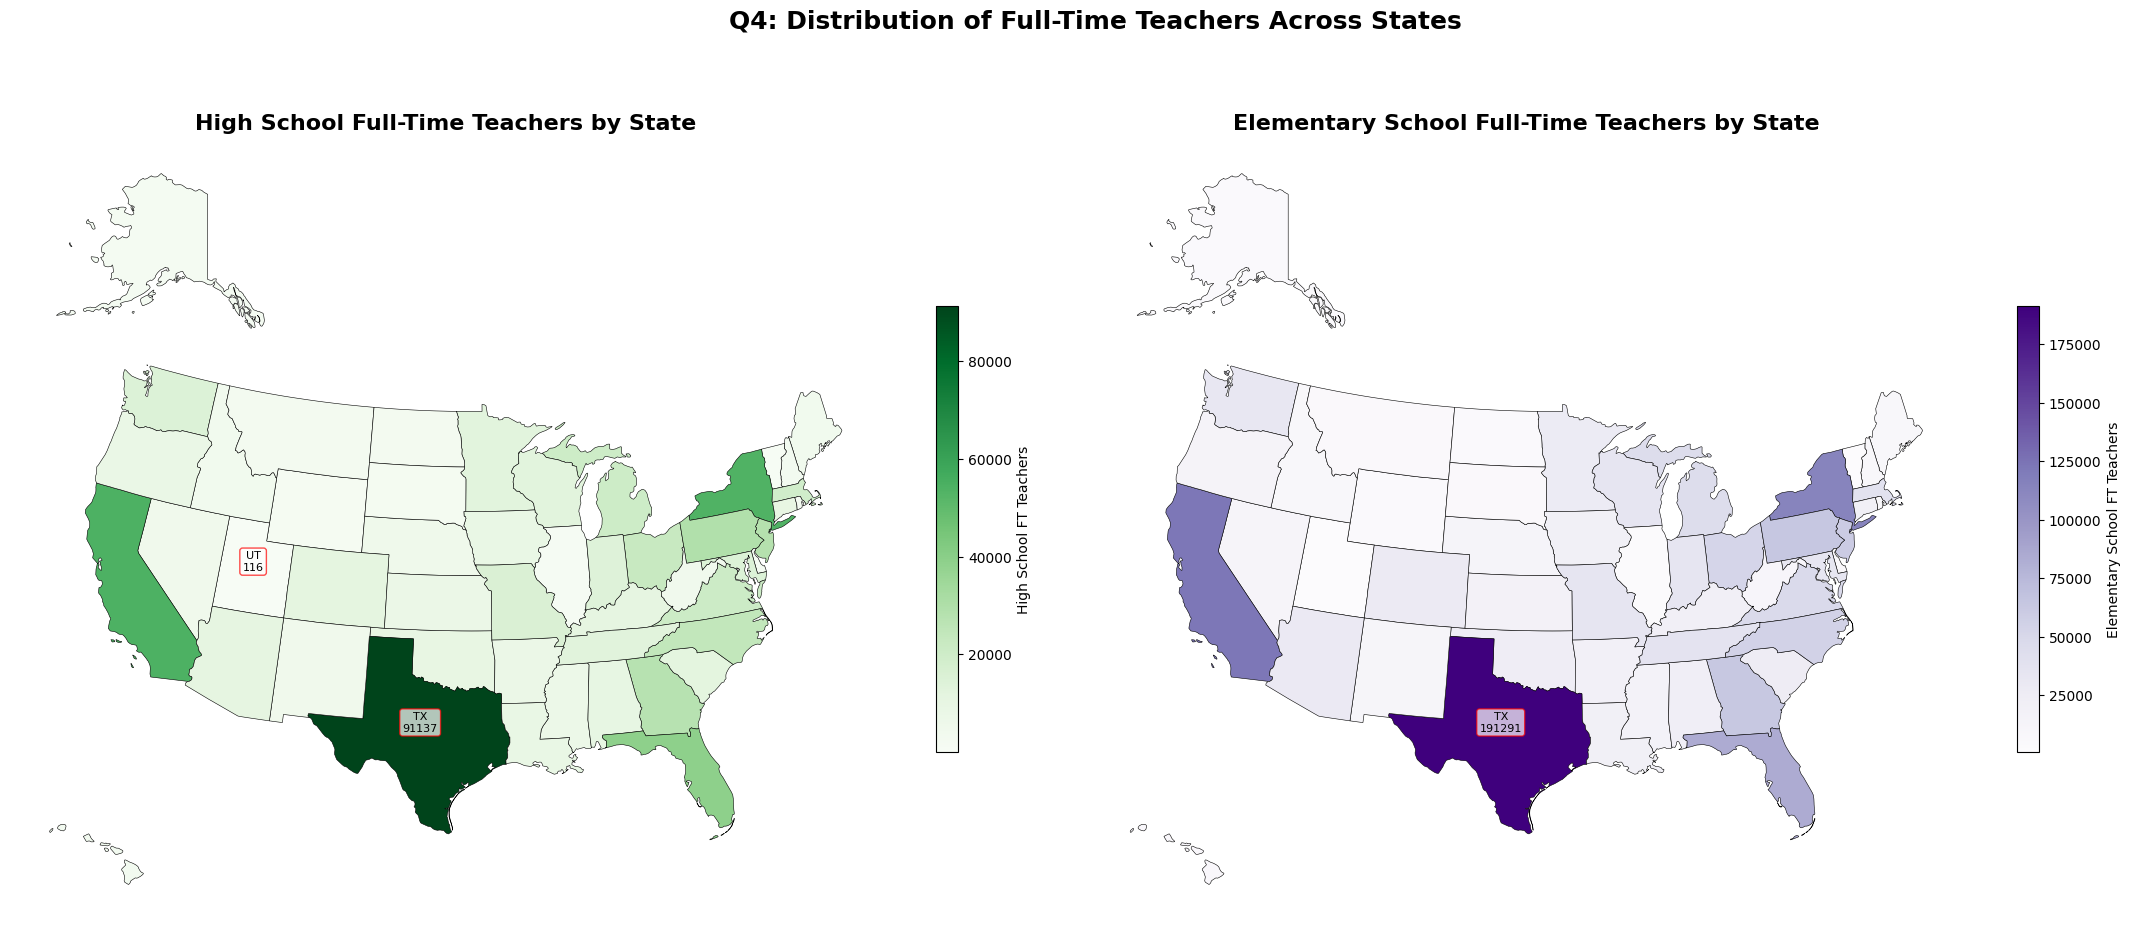


✅ Saved map figure to viz/eps/q4_ft_teacher_maps.eps

📊 Context (Q4 Maps):
• Data Quality: Analyzed 95,969 schools with valid teacher data out of 107,299 total
• Excluded 11,330 schools (missing FT_TEACHER=-999)
• Highest High School Teachers: TX (91,137)
• Lowest High School Teachers: UT (116)
• Highest Elementary Teachers: TX (191,291)
• Lowest Elementary Teachers: VI (285)


In [ ]:
# Q4 Map Visualization: Full-Time Teachers (High vs Elementary) by State
import os
import matplotlib.pyplot as plt
import geopandas as gpd

# State abbreviation mapping
state_abbrev_to_name = {state.abbr: state.name for state in us.states.STATES}

# Build DataFrames for High and Elementary teacher counts
high_t_df = high_teachers.reset_index(); high_t_df.columns = ['STATE','HighTeachers']
elem_t_df = elem_teachers.reset_index(); elem_t_df.columns = ['STATE','ElementaryTeachers']

high_t_df['StateName'] = high_t_df['STATE'].map(state_abbrev_to_name)
elem_t_df['StateName'] = elem_t_df['STATE'].map(state_abbrev_to_name)

# Load shapefile
us_states = gpd.read_file('US_State.shp')

high_t_geo = us_states.merge(high_t_df, on='StateName', how='left')
elem_t_geo = us_states.merge(elem_t_df, on='StateName', how='left')

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# High Teachers Map
high_t_geo.plot(column='HighTeachers', ax=axes[0], cmap='Greens', edgecolor='black', linewidth=0.4,
                legend=True, missing_kwds={'color':'lightgrey','label':'No data'},
                legend_kwds={'shrink':0.5,'label':'High School FT Teachers'})
axes[0].set_title('High School Full-Time Teachers by State', fontsize=16, fontweight='bold')
axes[0].axis('off')

# Annotate max/min
if high_teachers.size > 0:
    top_state = high_teachers.idxmax(); bottom_state = high_teachers.idxmin()
    for idx, row in high_t_geo.iterrows():
        if row.get('HighTeachers') and row['StateName'] in [state_abbrev_to_name.get(top_state), state_abbrev_to_name.get(bottom_state)]:
            centroid = row['geometry'].centroid
            axes[0].annotate(f"{row['STATE']}\n{int(row['HighTeachers'])}", xy=(centroid.x, centroid.y), ha='center', fontsize=8,
                             bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='red', alpha=0.7))

# Elementary Teachers Map
elem_t_geo.plot(column='ElementaryTeachers', ax=axes[1], cmap='Purples', edgecolor='black', linewidth=0.4,
                legend=True, missing_kwds={'color':'lightgrey','label':'No data'},
                legend_kwds={'shrink':0.5,'label':'Elementary School FT Teachers'})
axes[1].set_title('Elementary School Full-Time Teachers by State', fontsize=16, fontweight='bold')
axes[1].axis('off')

if elem_teachers.size > 0:
    top_elem_state = elem_teachers.idxmax(); bottom_elem_state = elem_teachers.idxmin()
    for idx, row in elem_t_geo.iterrows():
        if row.get('ElementaryTeachers') and row['StateName'] in [state_abbrev_to_name.get(top_elem_state), state_abbrev_to_name.get(bottom_elem_state)]:
            centroid = row['geometry'].centroid
            axes[1].annotate(f"{row['STATE']}\n{int(row['ElementaryTeachers'])}", xy=(centroid.x, centroid.y), ha='center', fontsize=8,
                             bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='red', alpha=0.7))

plt.suptitle('Q4: Distribution of Full-Time Teachers Across States', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.96])

os.makedirs('viz/eps', exist_ok=True)
plt.savefig('viz/eps/q4_ft_teacher_maps.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

print('\n✅ Saved map figure to viz/eps/q4_ft_teacher_maps.eps')
print('\n📊 Context (Q4 Maps):')
print(f"• Data Quality: Analyzed {len(valid_schools):,} schools with valid teacher data out of {len(schools):,} total")
print(f"• Excluded {len(schools) - len(valid_schools):,} schools (missing FT_TEACHER=-999)")
print(f"• Highest High School Teachers: {high_teachers.idxmax()} ({int(high_teachers.max()):,})")
print(f"• Lowest High School Teachers: {high_teachers.idxmin()} ({int(high_teachers.min()):,})")
print(f"• Highest Elementary Teachers: {elem_teachers.idxmax()} ({int(elem_teachers.max()):,})")
print(f"• Lowest Elementary Teachers: {elem_teachers.idxmin()} ({int(elem_teachers.min()):,})")

### Question 5: Enrollment Distribution and Teacher-to-Student Ratio

**Q:** Plot the distribution of Schools' ENROLLMENT and compare it with the plot in the Q3 and Q4. Indicate those three regions which have lowest ENROLLMENT to FT_TEACHER ratio.

In [ ]:
# Filter out invalid values (negative values are sentinel codes for missing data)
valid_enrollment_schools = schools[(schools['ENROLLMENT'] >= 0) & (schools['FT_TEACHER'] >= 0)].copy()

print(f"Schools with valid ENROLLMENT and FT_TEACHER data: {len(valid_enrollment_schools)}")
print(f"Excluded {len(schools) - len(valid_enrollment_schools)} schools with missing data\n")

# Aggregate ENROLLMENT by state and level
enrollment_data = valid_enrollment_schools.groupby(['STATE', 'LEVEL_'])['ENROLLMENT'].sum().reset_index()

# Pivot to get High and Elementary enrollment by state
enrollment_pivot = enrollment_data.pivot(index='STATE', columns='LEVEL_', values='ENROLLMENT').fillna(0)

# Get High and Elementary enrollment (levels are uppercase in data)
high_enrollment = enrollment_pivot.get('HIGH', pd.Series(dtype=float))
elem_enrollment = enrollment_pivot.get('ELEMENTARY', pd.Series(dtype=float))

# Calculate ENROLLMENT to FT_TEACHER ratio for each state/level
teacher_agg = valid_enrollment_schools.groupby(['STATE', 'LEVEL_']).agg({
    'ENROLLMENT': 'sum',
    'FT_TEACHER': 'sum'
}).reset_index()

teacher_agg['ratio'] = teacher_agg['ENROLLMENT'] / teacher_agg['FT_TEACHER']
teacher_agg['state_level'] = teacher_agg['STATE'] + ' - ' + teacher_agg['LEVEL_']

# Find 3 regions with lowest enrollment to FT_TEACHER ratio
lowest_ratios = teacher_agg.nsmallest(3, 'ratio')

print("Top 3 Regions with Lowest ENROLLMENT to FT_TEACHER Ratio (Students per Teacher):")
for idx, row in lowest_ratios.iterrows():
    print(f"{row['state_level']}: {row['ratio']:.2f} students/teacher")

Schools with valid ENROLLMENT and FT_TEACHER data: 95829
Excluded 11470 schools with missing data

Top 3 Regions with Lowest ENROLLMENT to FT_TEACHER Ratio (Students per Teacher):
MD - UNGRADED: 0.00 students/teacher
NE - UNGRADED: 0.00 students/teacher
NV - ADULT EDUCATION: 3.38 students/teacher


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


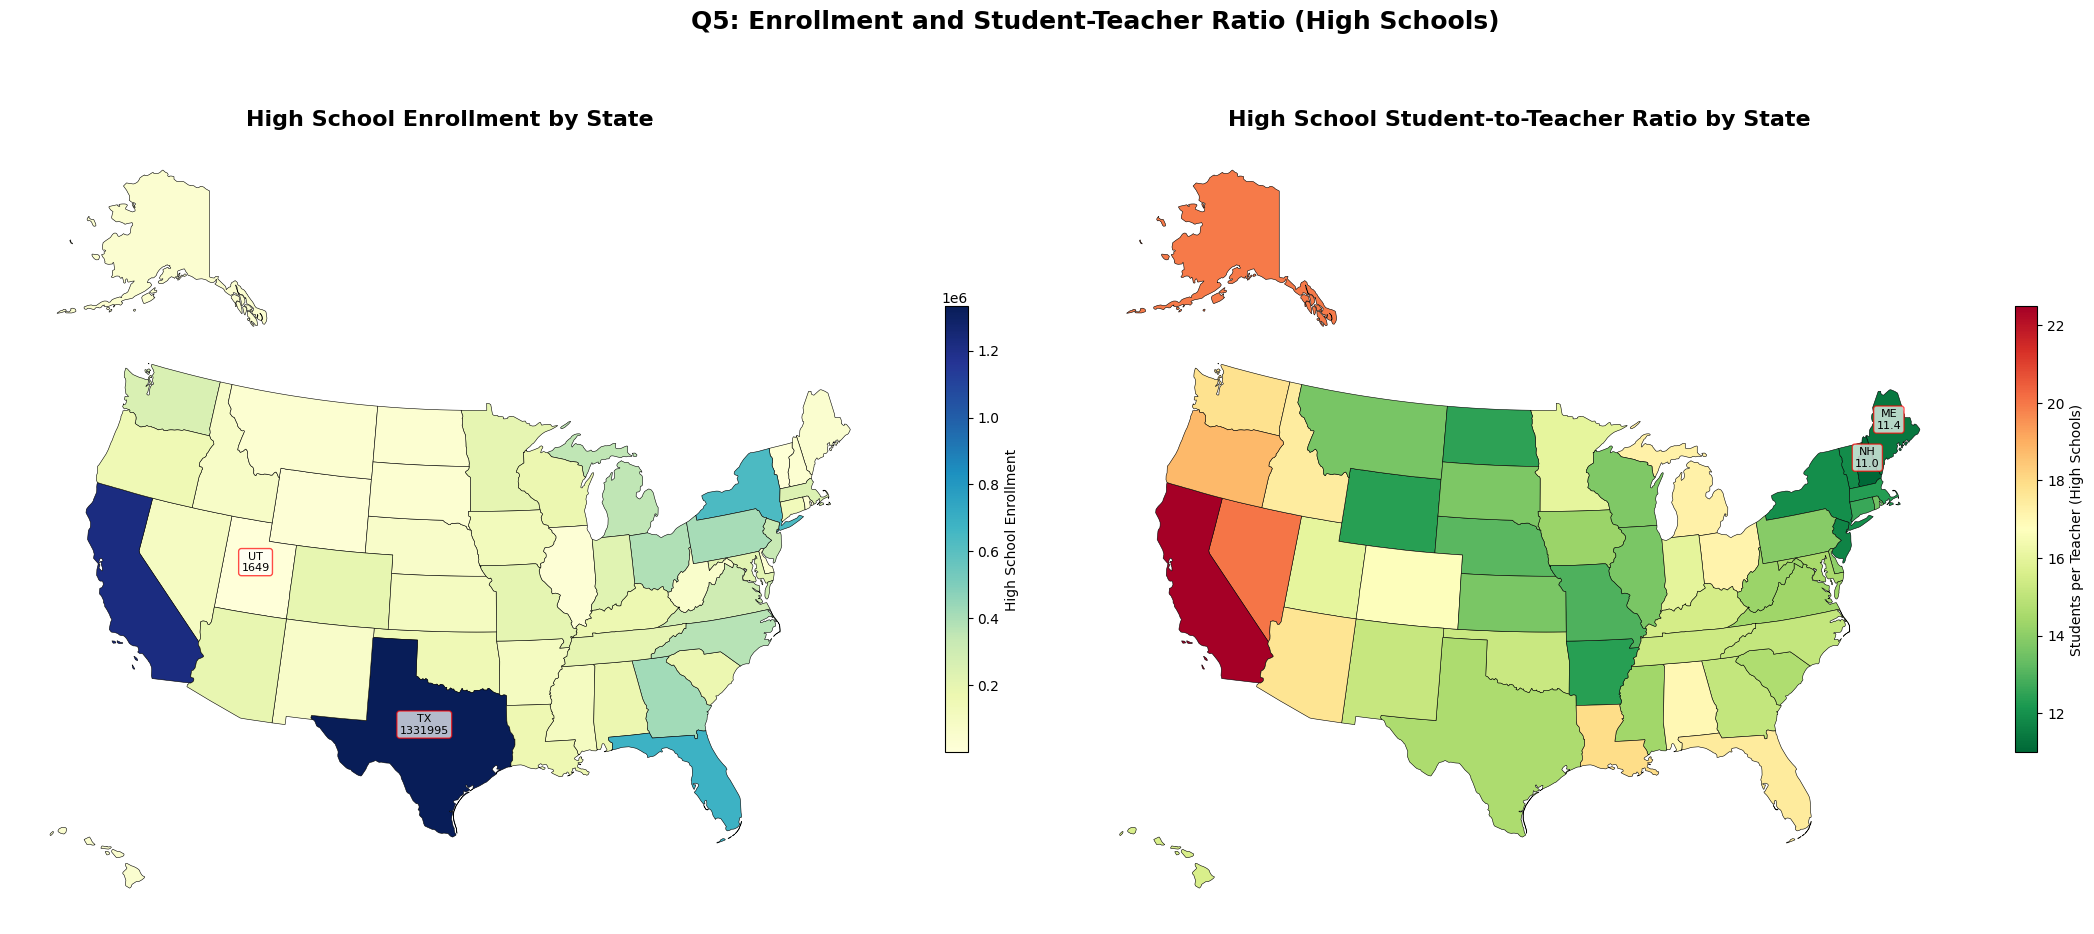


✅ Saved map figure to viz/eps/q5_enrollment_ratio_maps.eps

📊 Context (Q5 Maps):
• Data Quality: 95,829 schools with valid enrollment & teacher data; excluded 11,470
• Highest Enrollment State (High Schools): TX with 1,331,995 students
• Lowest Enrollment State (High Schools): UT with 1,649 students
• Three States with Lowest Student-Teacher Ratios (High Schools):
  → NH: 11.00 students/teacher
  → VI: 11.08 students/teacher
  → ME: 11.37 students/teacher
• Lower ratios (green) indicate more teachers per student and better potential attention.


In [ ]:
# Q5 Map Visualization: Enrollment and Student-Teacher Ratio (High Schools)
import os
import matplotlib.pyplot as plt
import geopandas as gpd

# State abbreviation mapping
state_abbrev_to_name = {state.abbr: state.name for state in us.states.STATES}

# High School enrollment series
high_enroll_df = high_enrollment.reset_index(); high_enroll_df.columns = ['STATE','HighEnrollment']
high_enroll_df['StateName'] = high_enroll_df['STATE'].map(state_abbrev_to_name)

# Ratio calculation restricted to HIGH level
ratio_high = teacher_agg[teacher_agg['LEVEL_']=='HIGH'][['STATE','ratio']].copy()
ratio_high.columns = ['STATE','StudentTeacherRatio']
ratio_high['StateName'] = ratio_high['STATE'].map(state_abbrev_to_name)

# Identify 3 states with lowest ratios (better individual attention)
lowest_ratio_high = ratio_high.nsmallest(3, 'StudentTeacherRatio')
lowest_ratio_set = set(lowest_ratio_high['STATE'])

# Load shapefile
us_states = gpd.read_file('US_State.shp')

enroll_geo = us_states.merge(high_enroll_df, on='StateName', how='left')
ratio_geo = us_states.merge(ratio_high, on='StateName', how='left')

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Enrollment Map
enroll_geo.plot(column='HighEnrollment', ax=axes[0], cmap='YlGnBu', edgecolor='black', linewidth=0.4,
                legend=True, missing_kwds={'color':'lightgrey','label':'No data'},
                legend_kwds={'shrink':0.5,'label':'High School Enrollment'})
axes[0].set_title('High School Enrollment by State', fontsize=16, fontweight='bold')
axes[0].axis('off')

# Annotate top & bottom enrollment
if high_enrollment.size > 0:
    top_enroll_state = high_enrollment.idxmax(); bottom_enroll_state = high_enrollment.idxmin()
    for idx, row in enroll_geo.iterrows():
        if row.get('HighEnrollment') and row['StateName'] in [state_abbrev_to_name.get(top_enroll_state), state_abbrev_to_name.get(bottom_enroll_state)]:
            centroid = row['geometry'].centroid
            axes[0].annotate(f"{row['STATE']}\n{int(row['HighEnrollment'])}", xy=(centroid.x, centroid.y), ha='center', fontsize=8,
                             bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='red', alpha=0.7))

# Student-Teacher Ratio Map (lower is better)
ratio_geo.plot(column='StudentTeacherRatio', ax=axes[1], cmap='RdYlGn_r', edgecolor='black', linewidth=0.4,
               legend=True, missing_kwds={'color':'lightgrey','label':'No data'},
               vmin=ratio_high['StudentTeacherRatio'].min(), vmax=ratio_high['StudentTeacherRatio'].max(),
               legend_kwds={'shrink':0.5,'label':'Students per Teacher (High Schools)'})
axes[1].set_title('High School Student-to-Teacher Ratio by State', fontsize=16, fontweight='bold')
axes[1].axis('off')

# Annotate three best (lowest ratio) states
for idx, row in ratio_geo.iterrows():
    if row.get('StudentTeacherRatio') and row['STATE'] in lowest_ratio_set:
        centroid = row['geometry'].centroid
        axes[1].annotate(f"{row['STATE']}\n{row['StudentTeacherRatio']:.1f}", xy=(centroid.x, centroid.y), ha='center', fontsize=8,
                         bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='red', alpha=0.7))

plt.suptitle('Q5: Enrollment and Student-Teacher Ratio (High Schools)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.96])

os.makedirs('viz/eps', exist_ok=True)
plt.savefig('viz/eps/q5_enrollment_ratio_maps.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

print('\n✅ Saved map figure to viz/eps/q5_enrollment_ratio_maps.eps')
print('\n📊 Context (Q5 Maps):')
print(f"• Data Quality: {len(valid_enrollment_schools):,} schools with valid enrollment & teacher data; excluded {len(schools) - len(valid_enrollment_schools):,}")
print(f"• Highest Enrollment State (High Schools): {high_enrollment.idxmax()} with {int(high_enrollment.max()):,} students")
print(f"• Lowest Enrollment State (High Schools): {high_enrollment.idxmin()} with {int(high_enrollment.min()):,} students")
print(f"• Three States with Lowest Student-Teacher Ratios (High Schools):")
for _, r in lowest_ratio_high.iterrows():
    print(f"  → {r['STATE']}: {r['StudentTeacherRatio']:.2f} students/teacher")
print("• Lower ratios (green) indicate more teachers per student and better potential attention.")

### Question 6: Global Corruption Analysis

#### The Hidden Cost of Corruption: A Global Perspective

Corruption remains one of the most significant barriers to sustainable development, economic growth, and social justice worldwide. Through analyzing the Transparency International Corruption Perceptions Index (CPI), we uncover critical patterns that reveal how corruption shapes our world.

In [4]:
# Install kagglehub for downloading Kaggle datasets
%pip install kagglehub

In [29]:
# Download Corruption Index dataset from Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("transparencyint/corruption-index")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'corruption-index' dataset.
Path to dataset files: /kaggle/input/corruption-index


In [7]:
# Explore the downloaded dataset
import os
import glob

# List all files in the dataset directory
files = glob.glob(os.path.join(path, '**', '*'), recursive=True)
print("Available files:")
for f in files:
    if os.path.isfile(f):
        print(f"  - {os.path.basename(f)}")

Available files:
  - index.csv
  - history.csv


In [32]:
# Load and explore the corruption data
# Find CSV files
csv_files = [f for f in glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)]
print(f"Found {len(csv_files)} CSV file(s)\n")

# Load the main dataset
corruption_df = pd.read_csv(csv_files[0])
# Rename Corruption Perceptions Index (CPI) to CPI 2016 Score
corruption_df.rename(columns={'Corruption Perceptions Index (CPI)': 'CPI 2016 Score'}, inplace=True)

print("Dataset shape:", corruption_df.shape)
print("\nColumn names:")
print(corruption_df.columns.tolist())
print("\nFirst few rows:")
print(corruption_df.head())
print("\nData types:")
print(corruption_df.dtypes)
print("\nBasic statistics:")
print(corruption_df.describe())

Found 2 CSV file(s)

Dataset shape: (176, 22)

Column names:
['CPI Rank', 'Country', 'Country Code', 'Region', 'CPI 2016 Score', 'Standard Error', 'Lower Confidence Interval', 'Upper Confidence Interval', 'World Bank CPIA', 'World Economic Forum EOS', 'Global Insight Country Risk Ratings', 'Bertelsmann Foundation Transformation Index', 'African Development Bank CPIA', 'IMD World Competitiveness Yearbook', 'Bertelsmann Foundation Sustainable Governance Index', 'World Justice Project Rule of Law Index', 'PRS International Country Risk Guide', 'Varities of Democracy Project', 'Economist Intelligence Unit Country Ratings', 'Freedom House Nations in Transit Ratings', 'PERC Asia Risk Guide', 'Sources']

First few rows:
   CPI Rank      Country Country Code                   Region  \
0         1  New Zealand          NZL             Asia Pacific   
1         1      Denmark          DNK  Europe and Central Asia   
2         3      Finland          FIN  Europe and Central Asia   
3         4  

**Context:** The Corruption Perceptions Index (CPI) scores countries on a scale from 0 (highly corrupt) to 100 (very clean). This choropleth map reveals stark regional patterns:
- **Blue/Green regions** (Nordic countries, New Zealand, Canada, Australia): Strong institutions and high transparency
- **Orange/Red regions** (parts of Africa, Middle East, Central Asia): Struggling with systemic corruption
- **Global divide**: 80-point gap between cleanest (New Zealand: 90) and most corrupt (Somalia: 10) countries

Sample world data columns: ['ADM0_DIF', 'ADMIN', 'ADM0_A3', 'NOTE_ADM0', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'ADM0_A3_VN', 'ADM0_A3_TR', 'ADM0_A3_ID', 'ADM0_A3_PL', 'ADM0_A3_GR', 'ADM0_A3_IT', 'ADM0_A3_NL', 'ADM0_A3_SE', 'ADM0_A3_BD', 'ADM0_A3_UA', 'ADM0_A3_UN', 'ADM0_A3_WB', 'FCLASS_ISO']


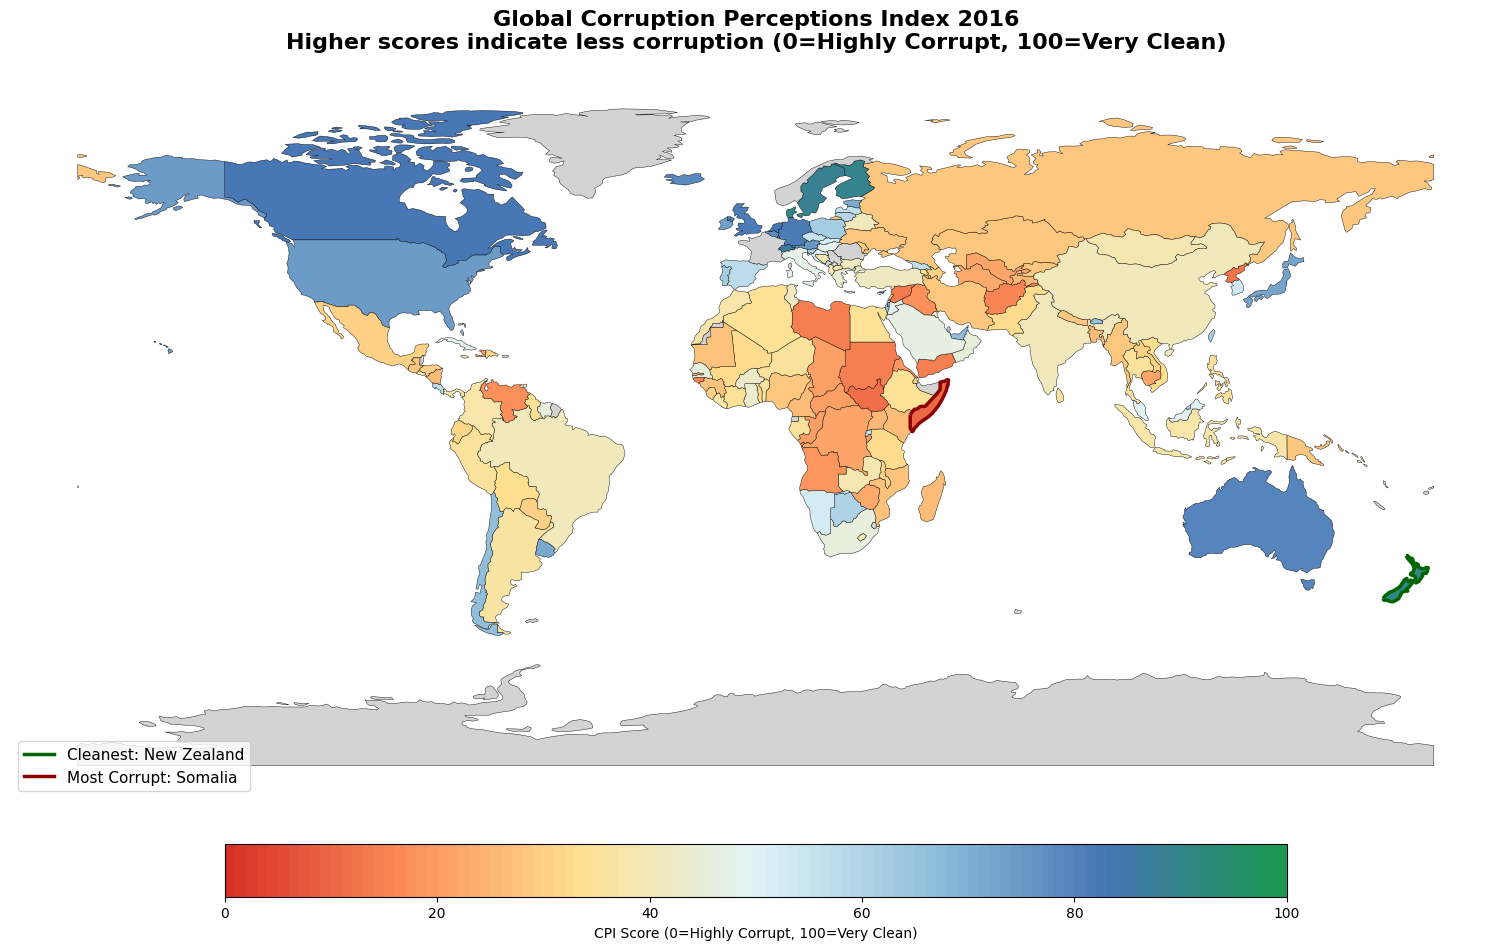


✅ Visualization saved to: viz/eps/q6_corruption_world_map.eps

📊 Key Insights:
• Cleanest Country: New Zealand (Score: 90)
• Most Corrupt Country: Somalia (Score: 10)
• Global Average: 42.9
• Countries scoring below 30 (high corruption): 46


In [33]:
# World Choropleth Map of Corruption Scores using matplotlib
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

# Load world geometries from Natural Earth
world_url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(world_url)

# Check columns - Natural Earth uses 'ISO_A3' or 'ADM0_A3' for 3-letter country codes
print("Sample world data columns:", [col for col in world.columns if 'ISO' in col or 'ADM' in col])

# Merge corruption data with world geometries
# Try common country code column names
if 'ISO_A3' in world.columns:
    world_corruption = world.merge(corruption_df, left_on='ISO_A3', right_on='Country Code', how='left')
elif 'ADM0_A3' in world.columns:
    world_corruption = world.merge(corruption_df, left_on='ADM0_A3', right_on='Country Code', how='left')
else:
    # Fallback to 'ADMIN' (country name)
    world_corruption = world.merge(corruption_df, left_on='ADMIN', right_on='Country', how='left')

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(18, 10))

# Create custom colormap: Red (corrupt) -> Yellow -> Green (clean)
colors = ['#d73027', '#fc8d59', '#fee090', '#e0f3f8', '#91bfdb', '#4575b4', '#1a9850']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('corruption', colors, N=n_bins)

# Plot the world map
world_corruption.plot(column='CPI 2016 Score',
                      ax=ax,
                      legend=True,
                      cmap=cmap,
                      edgecolor='black',
                      linewidth=0.3,
                      missing_kwds={'color': 'lightgray', 'label': 'No data'},
                      vmin=0,
                      vmax=100,
                      legend_kwds={'label': "CPI Score (0=Highly Corrupt, 100=Very Clean)",
                                   'orientation': "horizontal",
                                   'shrink': 0.6,
                                   'pad': 0.05})

# Highlight top and bottom countries
top_country = corruption_df.loc[corruption_df['CPI 2016 Score'].idxmax()]
bottom_country = corruption_df.loc[corruption_df['CPI 2016 Score'].idxmin()]

# Find and highlight these countries on map
top_geom = world_corruption[world_corruption['Country Code'] == top_country['Country Code']]
bottom_geom = world_corruption[world_corruption['Country Code'] == bottom_country['Country Code']]

if not top_geom.empty:
    top_geom.boundary.plot(ax=ax, color='darkgreen', linewidth=2.5)
if not bottom_geom.empty:
    bottom_geom.boundary.plot(ax=ax, color='darkred', linewidth=2.5)

ax.set_title('Global Corruption Perceptions Index 2016\nHigher scores indicate less corruption (0=Highly Corrupt, 100=Very Clean)',
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Add legend for highlighted countries
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='darkgreen', linewidth=2.5, label=f'Cleanest: {top_country["Country"]}'),
                   Line2D([0], [0], color='darkred', linewidth=2.5, label=f'Most Corrupt: {bottom_country["Country"]}')]
ax.legend(handles=legend_elements, loc='lower left', fontsize=11, frameon=True)

plt.tight_layout()
os.makedirs('viz/eps', exist_ok=True)
plt.savefig('viz/eps/q6_corruption_world_map.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved to: viz/eps/q6_corruption_world_map.eps")

# Key statistics
print(f"\n📊 Key Insights:")
print(f"• Cleanest Country: {corruption_df.loc[corruption_df['CPI 2016 Score'].idxmax(), 'Country']} (Score: {corruption_df['CPI 2016 Score'].max()})")
print(f"• Most Corrupt Country: {corruption_df.loc[corruption_df['CPI 2016 Score'].idxmin(), 'Country']} (Score: {corruption_df['CPI 2016 Score'].min()})")
print(f"• Global Average: {corruption_df['CPI 2016 Score'].mean():.1f}")
print(f"• Countries scoring below 30 (high corruption): {(corruption_df['CPI 2016 Score'] < 30).sum()}")

### Question 6 Extension: Corruption vs GDP Per Capita (2016)
We extend the global analysis by integrating 2016 GDP per capita (current US$) from World Development Indicators (indicator `NY.GDP.PCAP.CD`). Higher GDP per capita generally correlates with stronger institutions and lower perceived corruption.

In [34]:
# Fetch GDP per capita 2016 (Primary: World Bank API; Fallback: public datasets)
import requests, pandas as pd, re
api_url = 'https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?date=2016&format=json&per_page=20000'
resp = requests.get(api_url)
records = []
if resp.status_code == 200:
    try:
        data = resp.json()
        if isinstance(data, list) and len(data) >= 2:
            for e in data[1]:
                iso3 = e.get('country', {}).get('id')
                name = e.get('country', {}).get('value')
                val = e.get('value')
                if iso3 and name and val is not None and re.fullmatch(r'[A-Z]{3}', iso3):
                    records.append({'Country Code': iso3, 'Country Name': name, 'GDP_PC_2016': float(val)})
    except Exception:
        pass

gdp_2016 = pd.DataFrame(records)

# Fallback if API returned empty
if gdp_2016.empty:
    print('World Bank API returned no direct per-capita values; using fallback GDP + population datasets to derive per capita.')
    gdp_total_url = 'https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv'
    pop_url = 'https://raw.githubusercontent.com/datasets/population/master/data/population.csv'
    gdp_total = pd.read_csv(gdp_total_url)
    pop_df = pd.read_csv(pop_url)
    # Filter year 2016
    gdp_2016_total = gdp_total[gdp_total['Year'] == 2016].copy()
    pop_2016 = pop_df[pop_df['Year'] == 2016].copy()
    # Some country codes might be missing; ensure ISO code column names
    # gdp dataset uses Country Code, population uses Country Code
    merged = gdp_2016_total.merge(pop_2016[['Country Code','Value']], on='Country Code', how='inner', suffixes=('_GDP','_POP'))
    merged['GDP_PC_2016'] = merged['Value_GDP'] / merged['Value_POP']
    merged.rename(columns={'Country Name': 'Country Name'}, inplace=True)
    gdp_2016 = merged[['Country Code','Country Name','GDP_PC_2016']]

print('Computed GDP per capita COUNTRY rows (2016):', len(gdp_2016))
print(gdp_2016.head())

World Bank API returned no direct per-capita values; using fallback GDP + population datasets to derive per capita.
Computed GDP per capita COUNTRY rows (2016): 258
  Country Code                 Country Name  GDP_PC_2016
0          AFG                  Afghanistan   522.082216
1          AFE  Africa Eastern and Southern  1331.200983
2          AFW   Africa Western and Central  1611.767240
3          ALB                      Albania  4124.055390
4          DZA                      Algeria  4424.985290


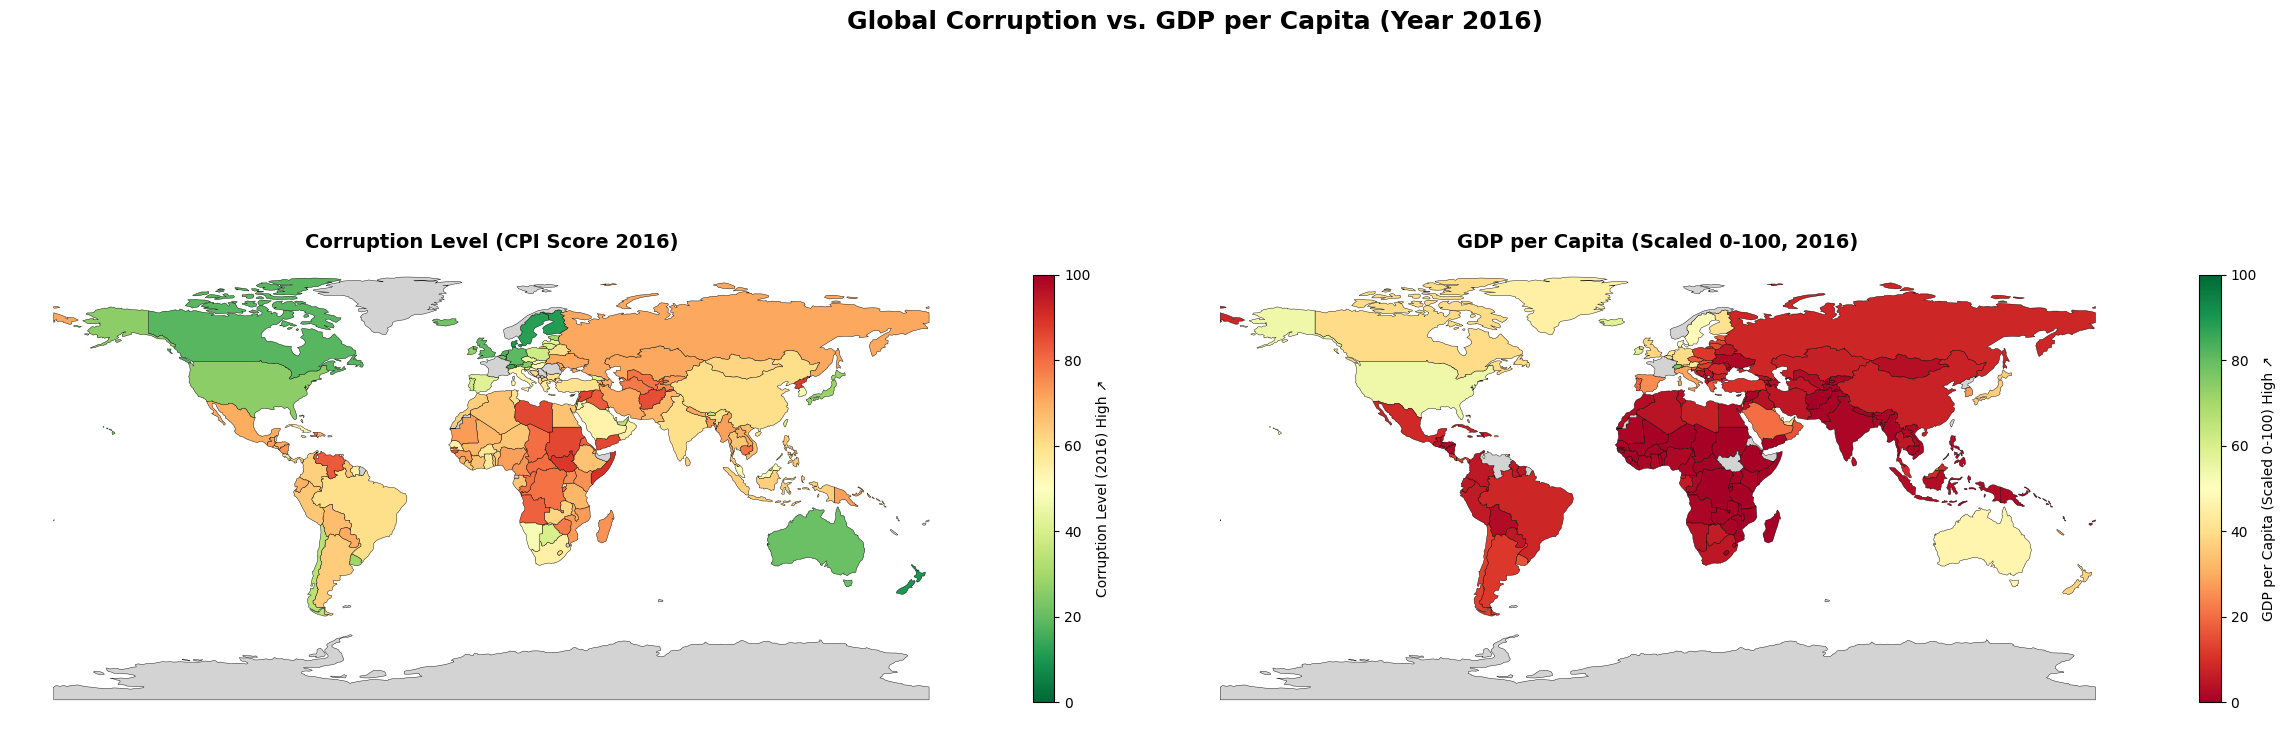


✅ Saved figure to viz/eps/q6_corruption_gdp_side_by_side.eps
CorruptionLevel non-null countries: 156
GDP per capita non-null countries: 163
GDP per capita raw range: $235 – $106,899
GDP per capita scaled range: 0 – 100 (min-max normalized)
Both indicators now on comparable 0-100 scales with unified color semantics.


In [36]:
# Merge GDP per capita with Corruption (CPI) and plot side-by-side
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load the corruption dataset
corruption_df = pd.read_csv(csv_files[0])
# Rename Corruption Perceptions Index (CPI) to CPI 2016 Score
corruption_df.rename(columns={'Corruption Perceptions Index (CPI)': 'CPI 2016 Score'}, inplace=True)

# Load world boundaries
world_url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(world_url)

# Merge CPI to world
if 'ISO_A3' in world.columns and 'Country Code' in corruption_df.columns:
    world_cpi = world.merge(corruption_df, left_on='ISO_A3', right_on='Country Code', how='left')
else:
    world_cpi = world.merge(corruption_df, left_on='ADMIN', right_on='Country', how='left')

# Clean GDP (already filtered) ensure numeric
gdp_2016_clean = gdp_2016.dropna(subset=['GDP_PC_2016']).copy()

# Merge GDP via ISO codes
if 'ISO_A3' in world_cpi.columns and 'Country Code' in gdp_2016_clean.columns:
    world_cpi_gdp = world_cpi.merge(gdp_2016_clean, left_on='ISO_A3', right_on='Country Code', how='left')
else:
    temp = gdp_2016_clean.copy()
    temp['Country Name Lower'] = temp['Country Name'].str.lower()
    world_cpi['ADMIN Lower'] = world_cpi['ADMIN'].str.lower()
    world_cpi_gdp = world_cpi.merge(temp[['Country Name Lower','GDP_PC_2016']], left_on='ADMIN Lower', right_on='Country Name Lower', how='left')
    world_cpi_gdp.drop(columns=['Country Name Lower'], inplace=True)

# Derive CorruptionLevel (higher = more corruption)
if 'CPI 2016 Score' in world_cpi_gdp.columns:
    world_cpi_gdp['CorruptionLevel'] = 100 - pd.to_numeric(world_cpi_gdp['CPI 2016 Score'], errors='coerce')

# Scale GDP to 0-100 range using min-max normalization
gdp_available = world_cpi_gdp['GDP_PC_2016'].notna().sum()
if gdp_available > 0:
    gdp_min_raw = world_cpi_gdp['GDP_PC_2016'].min()
    gdp_max_raw = world_cpi_gdp['GDP_PC_2016'].max()
    # Min-max normalization: (x - min) / (max - min) * 100
    world_cpi_gdp['GDP_Scaled'] = ((world_cpi_gdp['GDP_PC_2016'] - gdp_min_raw) / (gdp_max_raw - gdp_min_raw)) * 100
else:
    gdp_min_raw, gdp_max_raw = 0, 1
    world_cpi_gdp['GDP_Scaled'] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(24, 9))

# Corruption map (red=high corruption)
if 'CorruptionLevel' in world_cpi_gdp.columns and world_cpi_gdp['CorruptionLevel'].notna().any():
    world_cpi_gdp.plot(column='CorruptionLevel', ax=axes[0], cmap='RdYlGn_r', edgecolor='black', linewidth=0.3,
                       missing_kwds={'color':'lightgray','label':'No data'}, vmin=0, vmax=100,
                       legend=True, legend_kwds={'shrink':0.55,'label':'Corruption Level (2016) High ↗'})
    axes[0].set_title('Corruption Level (CPI Score 2016)', fontsize=14, fontweight='bold')
else:
    axes[0].text(0.5,0.5,'Corruption data unavailable', ha='center', va='center', fontsize=12)
axes[0].axis('off')

# GDP per capita map (scaled 0-100, red=low, green=high)
if gdp_available > 0 and world_cpi_gdp['GDP_Scaled'].notna().any():
    world_cpi_gdp.plot(column='GDP_Scaled', ax=axes[1], cmap='RdYlGn', edgecolor='black', linewidth=0.3,
                       missing_kwds={'color':'lightgray','label':'No data'}, vmin=0, vmax=100,
                       legend=True, legend_kwds={'shrink':0.55,'label':'GDP per Capita (Scaled 0-100) High ↗'})
    axes[1].set_title('GDP per Capita (Scaled 0-100, 2016)', fontsize=14, fontweight='bold')
else:
    axes[1].text(0.5,0.5,'GDP data unavailable', ha='center', va='center', fontsize=12)
axes[1].axis('off')

plt.suptitle('Global Corruption vs. GDP per Capita (Year 2016)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.94])
os.makedirs('viz/eps', exist_ok=True)
plt.savefig('viz/eps/q6_corruption_gdp_side_by_side.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

print('\n✅ Saved figure to viz/eps/q6_corruption_gdp_side_by_side.eps')
if 'CorruptionLevel' in world_cpi_gdp.columns:
    print(f"CorruptionLevel non-null countries: {(world_cpi_gdp['CorruptionLevel'].notna()).sum()}")
print(f"GDP per capita non-null countries: {gdp_available}")
if gdp_available > 0:
    print(f"GDP per capita raw range: ${gdp_min_raw:,.0f} – ${gdp_max_raw:,.0f}")
    print(f"GDP per capita scaled range: 0 – 100 (min-max normalized)")
    print(f"Both indicators now on comparable 0-100 scales with unified color semantics.")